### **Wholesale Customer Segmentation Using Hierarchical Clustering**
---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv('Wholesale customers data.csv')
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [4]:
df.nunique()

Channel               2
Region                3
Fresh               433
Milk                421
Grocery             430
Frozen              426
Detergents_Paper    417
Delicassen          403
dtype: int64

In [5]:
df.isnull().sum()

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [23]:
df["Channel"].value_counts()

Channel
1    298
2    142
Name: count, dtype: int64

In [24]:
df["Region"].value_counts()

Region
3    316
1     77
2     47
Name: count, dtype: int64

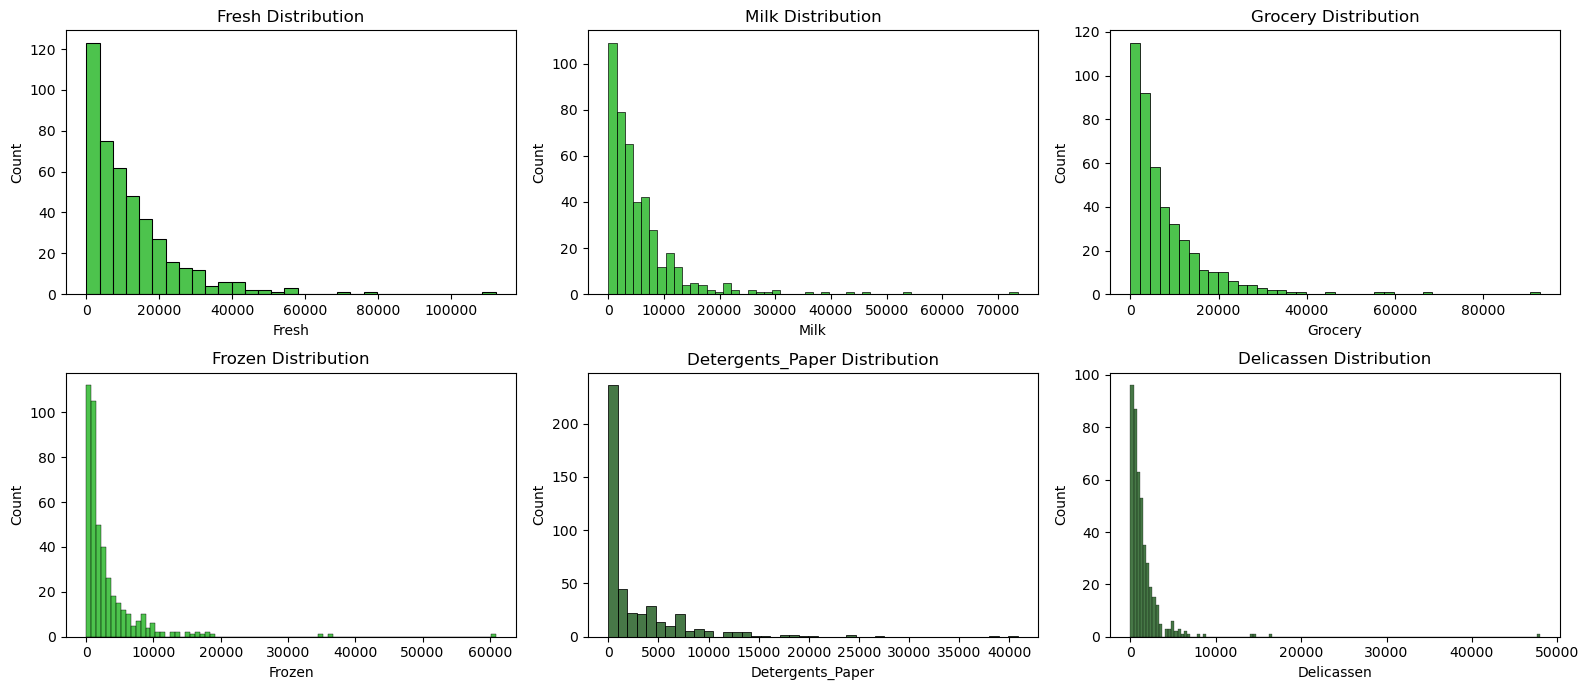

In [32]:
cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
colors = ["#11AF11"] * 4 + ["#094B09"] * 2

fig, ax = plt.subplots(2, 3, figsize=(16, 7))
ax = ax.flatten()

for i, col in enumerate(cols):
    sns.histplot(data=df, x=col, color=colors[i], ax=ax[i])
    ax[i].set_title(f'{col} Distribution')

plt.tight_layout()
plt.show()

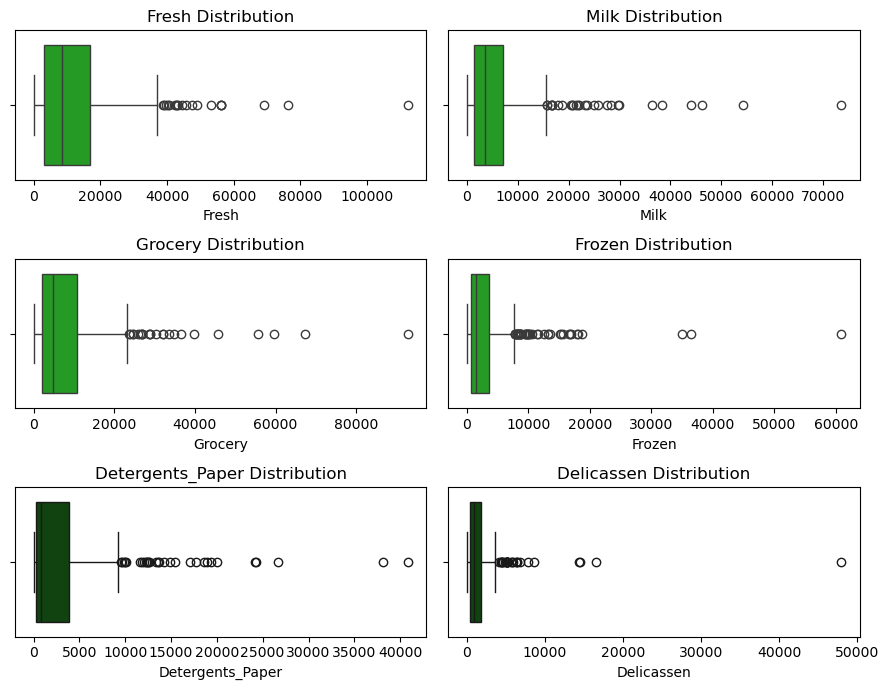

In [33]:
fig, ax = plt.subplots(3, 2, figsize=(9, 7))
colors = ["#11AF11"] * 4 + ["#094B09"] * 2
ax = ax.flatten()

for i, col in enumerate(cols):
    sns.boxplot(data=df, x=col, color=colors[i], ax=ax[i])
    ax[i].set_title(f'{col} Distribution')

plt.tight_layout()
plt.show()

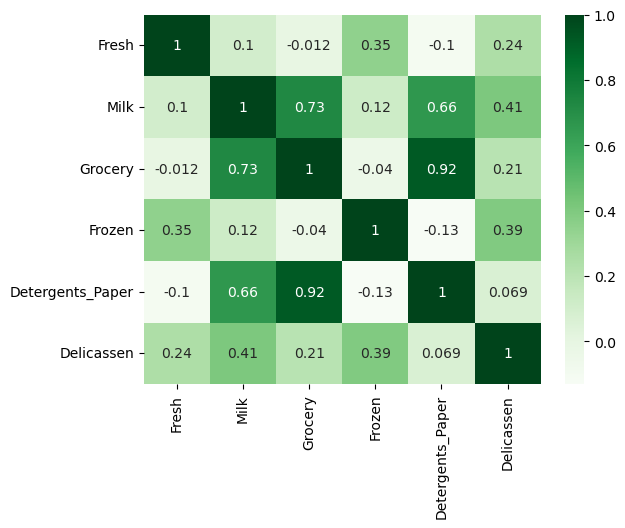

In [34]:
df_num = df[['Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen']]
sns.heatmap(df_num.corr(), annot=True, cmap = 'Greens')
plt.show()

In [ ]:
g = df.groupby('Channel').median()
g.drop('Region', axis=1, inplace=True)
g

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Channel,,,,,,
1,9581.5,2157.0,2684.0,2057.5,385.5,821.0
2,5993.5,7812.0,12390.0,1081.0,5614.5,1350.0


In [14]:
df_channel_one = g.iloc[0]
df_channel_two = g.iloc[1]

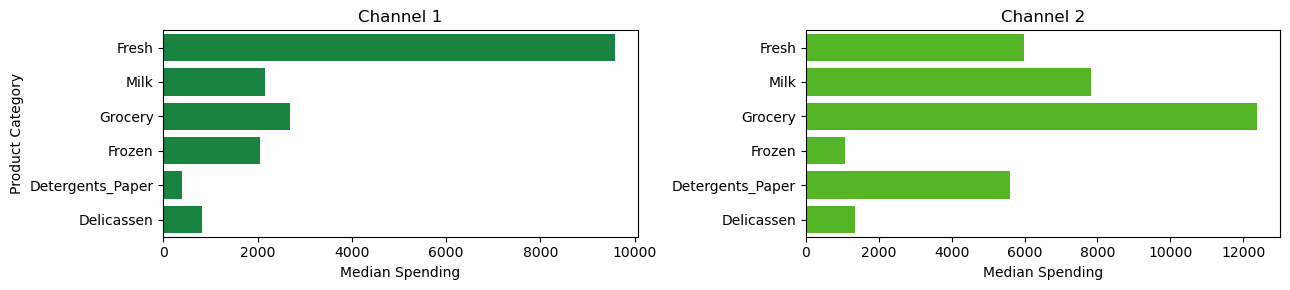

In [42]:
fig , ax = plt.subplots(1,2,figsize=(13,3))
sns.barplot(x=df_channel_one,y=df_channel_one.index,color="#08943D",ax = ax[0])
ax[0].set_title('Channel 1')
ax[0].set_ylabel('Product Category')
ax[0].set_xlabel('Median Spending')

sns.barplot(x=df_channel_two,y=df_channel_two.index,color="#4BCE0F",ax = ax[1])
ax[1].set_title('Channel 2')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Spending')

plt.tight_layout()
plt.show()

In [16]:
g = df.groupby('Region').median()
g.drop('Channel',axis=1,inplace=True)
g

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Region,,,,,,
1,7363.0,3748.0,3838.0,1801.0,737.0,806.0
2,8090.0,2374.0,6114.0,1455.0,811.0,898.0
3,8752.5,3684.5,4732.0,1498.0,856.0,994.0


In [17]:
region_one = g.iloc[0]
region_two = g.iloc[1]
region_three = g.iloc[2]

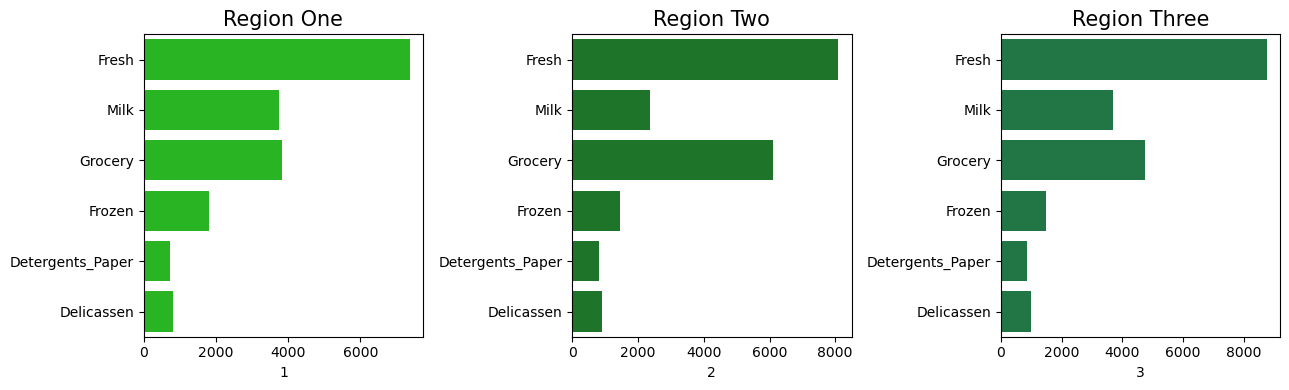

In [46]:
fig , ax = plt.subplots(1,3,figsize=(13,4))

sns.barplot(x=region_one,y=region_one.index,color="#12CC0B",ax = ax[0])
ax[0].set_title('Region One',fontsize=15)
ax[0].set_ylabel('')

sns.barplot(x=region_two,y=region_two.index,color="#108320",ax = ax[1])
ax[1].set_title('Region Two',fontsize=15)
ax[1].set_ylabel('')

sns.barplot(x=region_three,y=region_three.index,color="#148342",ax = ax[2])
ax[2].set_title('Region Three',fontsize=15)
ax[2].set_ylabel('')

plt.tight_layout()
plt.show()



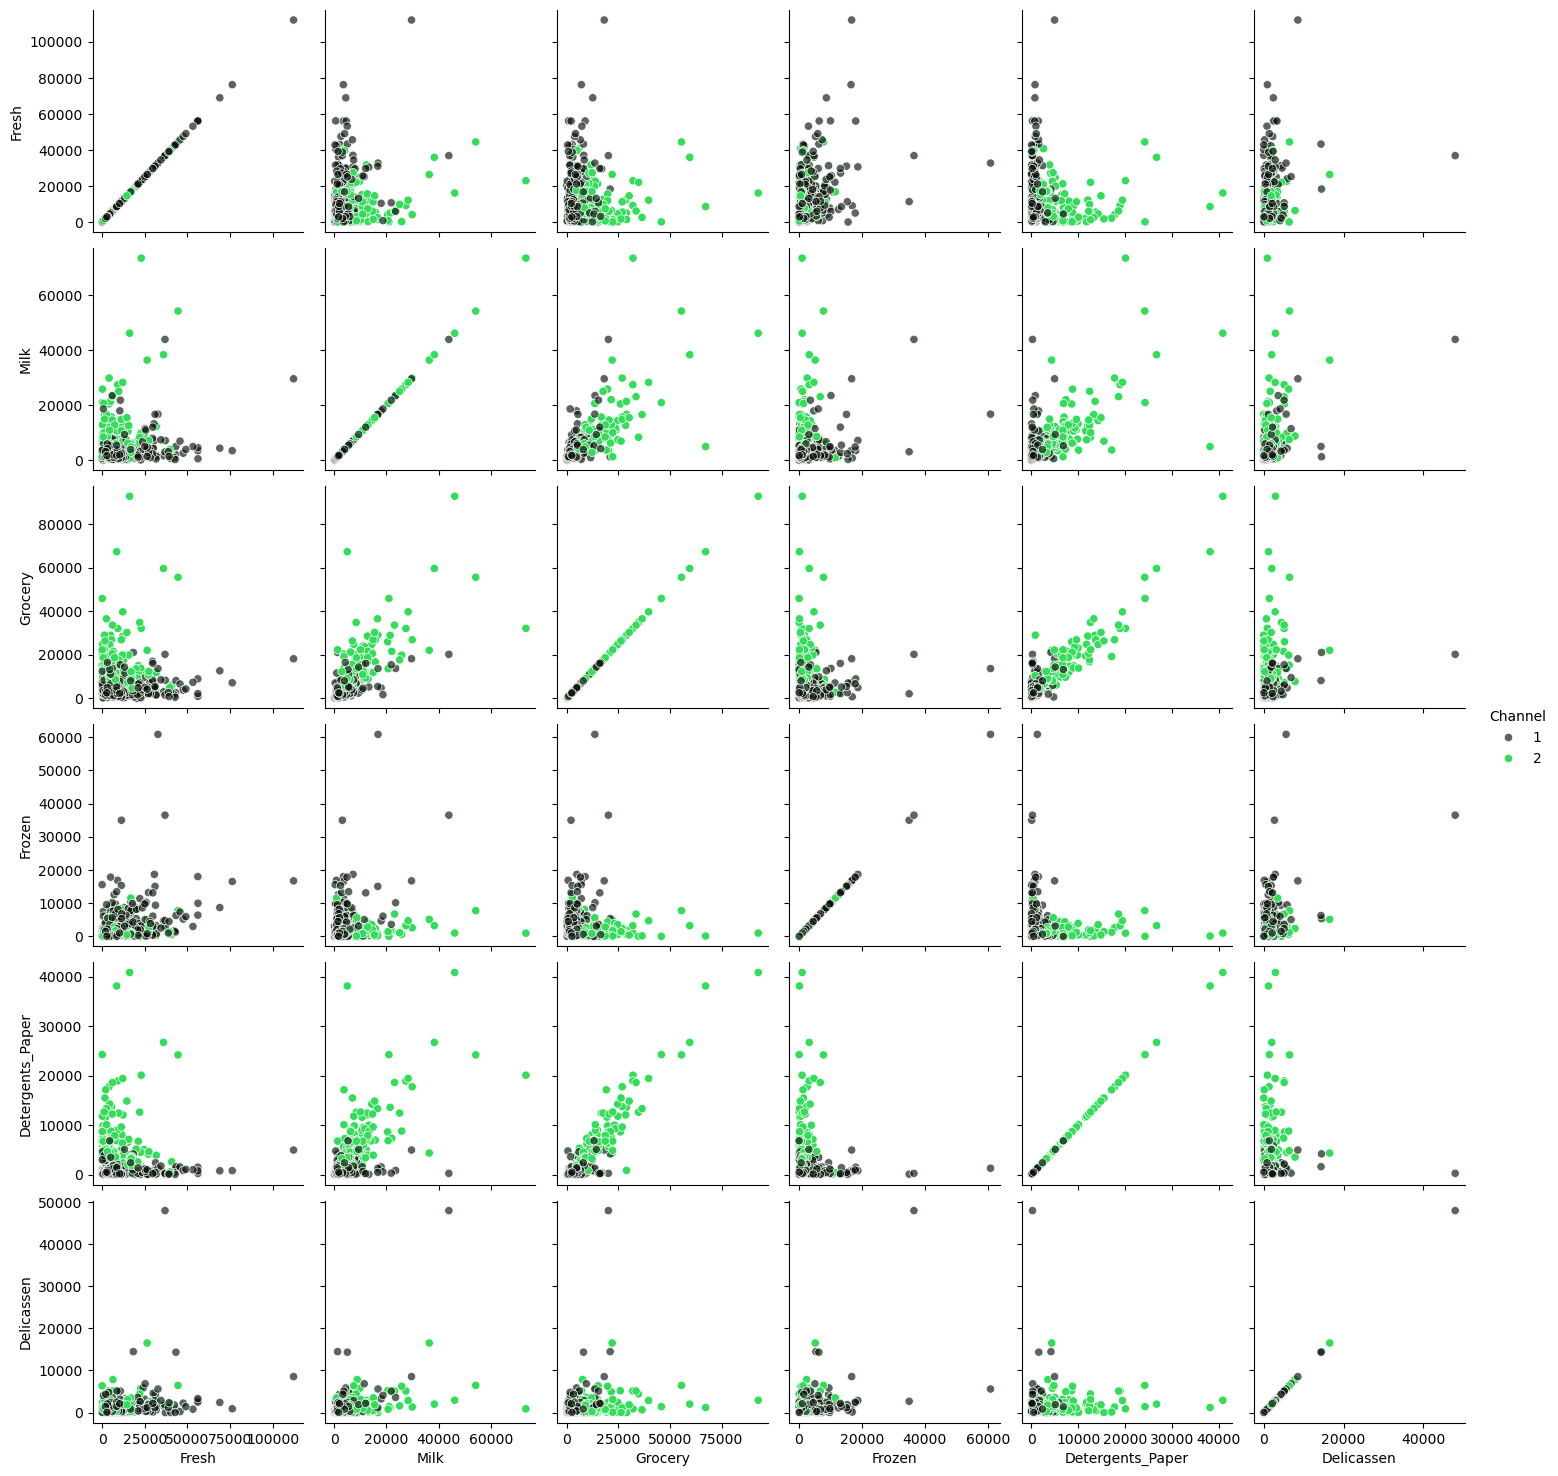

In [19]:
df_num = df.drop('Region',axis=1)
sns.pairplot(df_num ,diag_kind=None,hue='Channel',palette=["#061408A7","#34DD59"])
plt.show()

In [20]:
Features = df.drop(columns=['Channel','Region'],axis=1)
Features_log = np.log(Features)

In [21]:
scalar = StandardScaler()
features_scaled = scalar.fit_transform(Features_log)

### **Determine K clusters**
---

In [22]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

#### **Dendrogram (Ward linkage)**
---

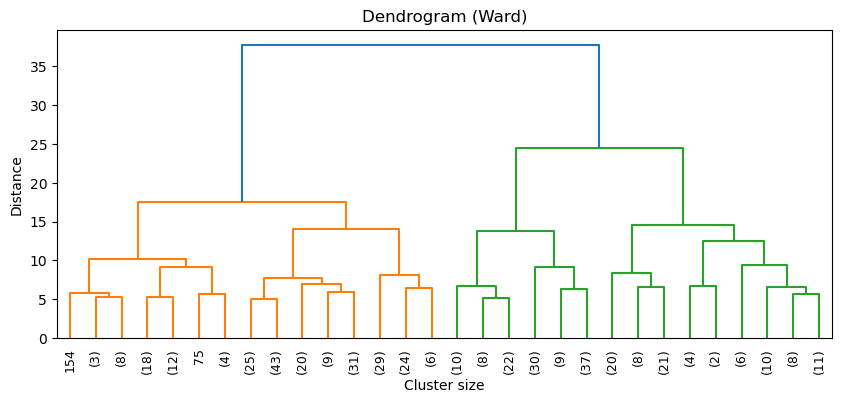

In [54]:
Z = linkage(features_scaled, method='ward')

plt.figure(figsize=(10, 4))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=9)
plt.title('Dendrogram (Ward)')
plt.xlabel('Cluster size')
plt.ylabel('Distance')
plt.show()

#### **Silhouette score**
---

In [55]:
k_range = range(2, 11)
sil_scores = []
for k in k_range:
    labels = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(features_scaled)
    sil_scores.append(silhouette_score(features_scaled, labels))

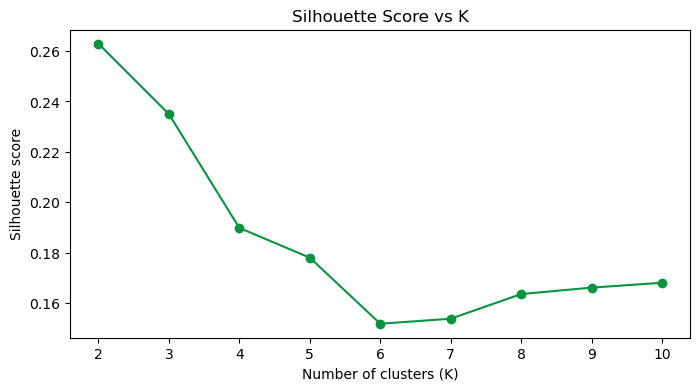

In [56]:
plt.figure(figsize=(8, 4))
plt.plot(k_range, sil_scores, marker='o', color="#08943D")
plt.title('Silhouette Score vs K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette score')
plt.show()

In [58]:
for k, s in zip(k_range, sil_scores):
    print(f'K={k}: {s:.3f}')

K=2: 0.263
K=3: 0.235
K=4: 0.190
K=5: 0.178
K=6: 0.152
K=7: 0.154
K=8: 0.164
K=9: 0.166
K=10: 0.168


#### **The final model**
---

In [59]:
model = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels = model.fit_predict(features_scaled)

df['Cluster'] = labels

In [60]:
print(pd.crosstab(df['Cluster'], df['Channel']))

Channel    1    2
Cluster          
0         71  135
1        227    7


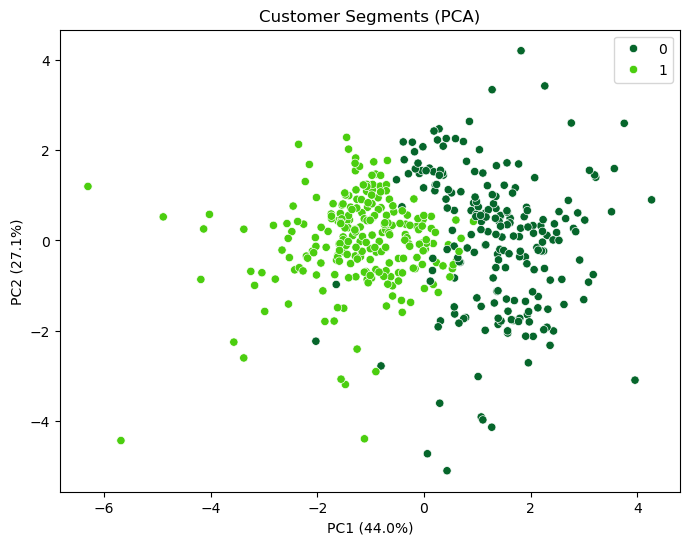

In [62]:
pca = PCA(n_components=2)
pcs = pca.fit_transform(features_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=pcs[:, 0], y=pcs[:, 1], hue=labels, palette=["#06662B", "#4BCE0F"])
plt.title('Customer Segments (PCA)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.show()

In [66]:
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

for i, (e, c) in enumerate(zip(explained, cumulative), 1):
    print(f'PC{i}: {e:.1%}  |  Cumulative: {c:.1%}')

PC1: 44.0%  |  Cumulative: 44.0%
PC2: 27.1%  |  Cumulative: 71.1%


                   PC1   PC2
Fresh            -0.10  0.59
Milk              0.54  0.13
Grocery           0.57 -0.01
Frozen           -0.14  0.59
Detergents_Paper  0.55 -0.07
Delicassen        0.21  0.53


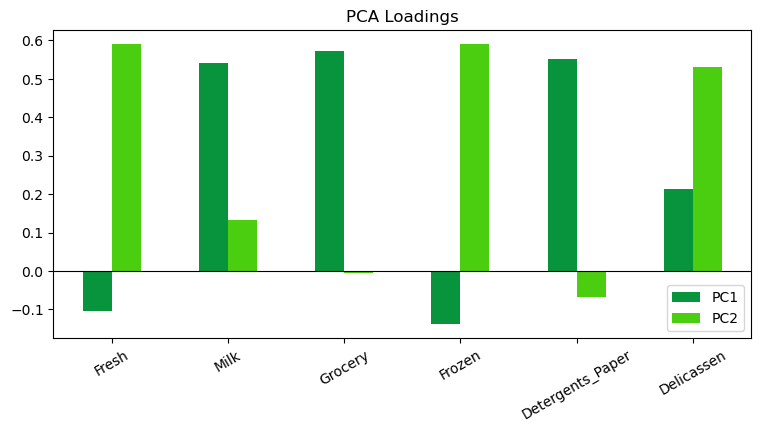

In [67]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=Features.columns
)
print(loadings.round(2))

loadings.plot(kind='bar', figsize=(9, 4), color=["#08943D", "#4BCE0F"])
plt.title('PCA Loadings')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=30)
plt.show()

#### **Profiling**
---

          Fresh    Milk  Grocery  Frozen  Detergents_Paper  Delicassen
Cluster                                                               
0        6410.5  7226.0  10842.5  1369.5            4103.0      1460.0
1        9409.5  1726.5   2256.5  1697.5             300.0       695.0


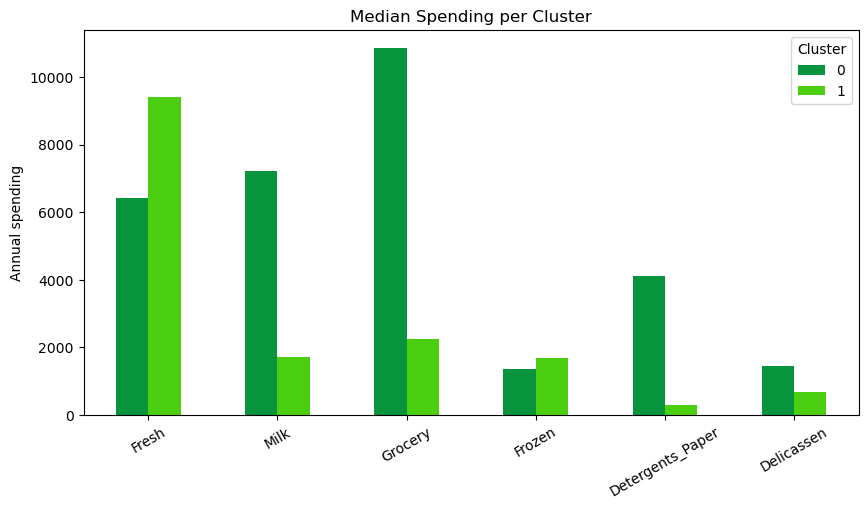

In [68]:
profile = df.groupby('Cluster')[['Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen']].median()
print(profile)

profile.T.plot(kind='bar', figsize=(10, 5), color=["#08943D", "#4BCE0F"])
plt.title('Median Spending per Cluster')
plt.ylabel('Annual spending')
plt.xticks(rotation=30)
plt.show()

In [70]:
df['Segment'] = df['Cluster'].map({0: 'Household & Packaged', 1: 'Fresh-Focused'})

print(df['Segment'].value_counts())

Segment
Fresh-Focused           234
Household & Packaged    206
Name: count, dtype: int64


In [71]:
print(pd.crosstab(df['Segment'], df['Channel'], normalize='index').round(2))

Channel                  1     2
Segment                         
Fresh-Focused         0.97  0.03
Household & Packaged  0.34  0.66


In [ ]:
# Conclusion

# Approach: 
# Applied log transformation and standardization to the six spending features, 
# then used Ward-linkage hierarchical clustering. The number of clusters was chosen using 
# the dendrogram and silhouette scores, both of which favored K=2 (silhouette = 0.263).


# Key findings:
# - Detergents_Paper is the strongest discriminating feature (~14x higher in Household & Packaged).
# - Milk, Grocery and Detergents_Paper move together (PC1, 44% of variance), which separates the two segments.
# - Frozen spending is similar across segments and does not differentiate customers.
# - The clusters, built without using the Channel label, match the actual Channel for ~82% of customers.

# Business implications:
# - Offer bundles of Grocery, Milk and Detergents_Paper to the Household & Packaged segment.
# - Focus Fresh-product promotions and delivery reliability on the Fresh-Focused segment.

# Limitations:
# - The silhouette score is low (0.26), so the segments overlap and boundaries are not sharp.
# - 71 Horeca customers fall into the Household & Packaged cluster, likely because their purchasing behavior resembles retail.
# - The first two principal components explain 71.1% of variance, so the 2D plot omits some structure.
# - Outliers were reduced by the log transform but not removed.